In [1]:
from PIL import Image
from io import BytesIO
import requests
from rfdetr import RFDETRBase
from rfdetr.util.coco_classes import COCO_CLASSES
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device detectado: {device}")

Device detectado: cuda


In [3]:
# Caminhos do dataset
ROOT_DIR = "../../SVRDD_COCO"
OUTPUT_PATH = "./output_rfdetr_synth"
#CHECKPOINT = "/workspace/RF_DETR/output_rfdetr_final/checkpoint0034.pth"

model = RFDETRBase()

Loading pretrain weights


In [ ]:
model.train(
    dataset_dir=ROOT_DIR,
    epochs=40,
    batch_size=8,
    grad_accum_steps=2,
    lr=1e-4,
    output_dir=OUTPUT_PATH,
    device=device,
    tensorboard=True,
    resolution=1064,
    checkpoint_interval=5
)

TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir ./output_rfdetr_final' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=7, grad_accum_steps=2, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=8, weight_decay=0.0001, epochs=100, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=3, dim_feedforward=2048, hidden_dim=256, sa_nhead

fatal: not a git repository (or any of the parent directories): .git


Done (t=0.51s)
creating index...
index created!
[1288]
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Get benchmark
Start training
Grad accum steps:  2
Total batch size:  16
LENGTH OF DATA LOADER: 375


Epoch: [0]  [  0/375]  eta: 0:25:51  lr: 0.000100  class_error: 75.55  loss: 24.3979 (24.3979)  loss_ce: 1.4114 (1.4114)  loss_bbox: 1.7495 (1.7495)  loss_giou: 2.7030 (2.7030)  loss_ce_0: 1.3481 (1.3481)  loss_bbox_0: 2.0475 (2.0475)  loss_giou_0: 2.8816 (2.8816)  loss_ce_1: 1.4186 (1.4186)  loss_bbox_1: 1.8200 (1.8200)  loss_giou_1: 2.7500 (2.7500)  loss_ce_enc: 1.2348 (1.2348)  loss_bbox_enc: 2.0522 (2.0522)  loss_giou_enc: 2.9814 (2.9814)  loss_ce_unscaled: 1.4114 (1.4114)  class_error_unscaled: 75.5495 (75.5495)  loss_bbox_unscaled: 0.3499 (0.3499)  loss_giou_unscaled: 1.3515 (1.3515)  cardinality_error_unscaled: 3860.6250 (3860.6250)  loss_ce_0_unscaled: 1.3481 (1.3481)  loss_bbox_0_unscaled: 0.4095 (0.4095)  loss_giou_0_unscaled: 1.4408 (1.4408)  cardinality_error_0_unscaled: 3865.7500 (3865.7500)  loss_ce_1_unscaled: 1.4186 (1.4186)  loss_bbox_1_unscaled: 0.3640 (0.3640)  loss_giou_1_unscaled: 1.3750 (1.3750)  cardinality_error_1_unscaled: 3851.8750 (3851.8750)  loss_ce_enc_uns

KeyboardInterrupt: 

# Inference

Loading pretrain weights


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


image = <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x1024 at 0x77813440FF10>


detections = Detections(xyxy=array([[5.8475494e-01, 5.2523376e+02, 2.4967578e+02, 6.6402161e+02]],
      dtype=float32), mask=None, confidence=array([0.93482363], dtype=float32), class_id=array([3]), tracker_id=None, data={}, metadata={})


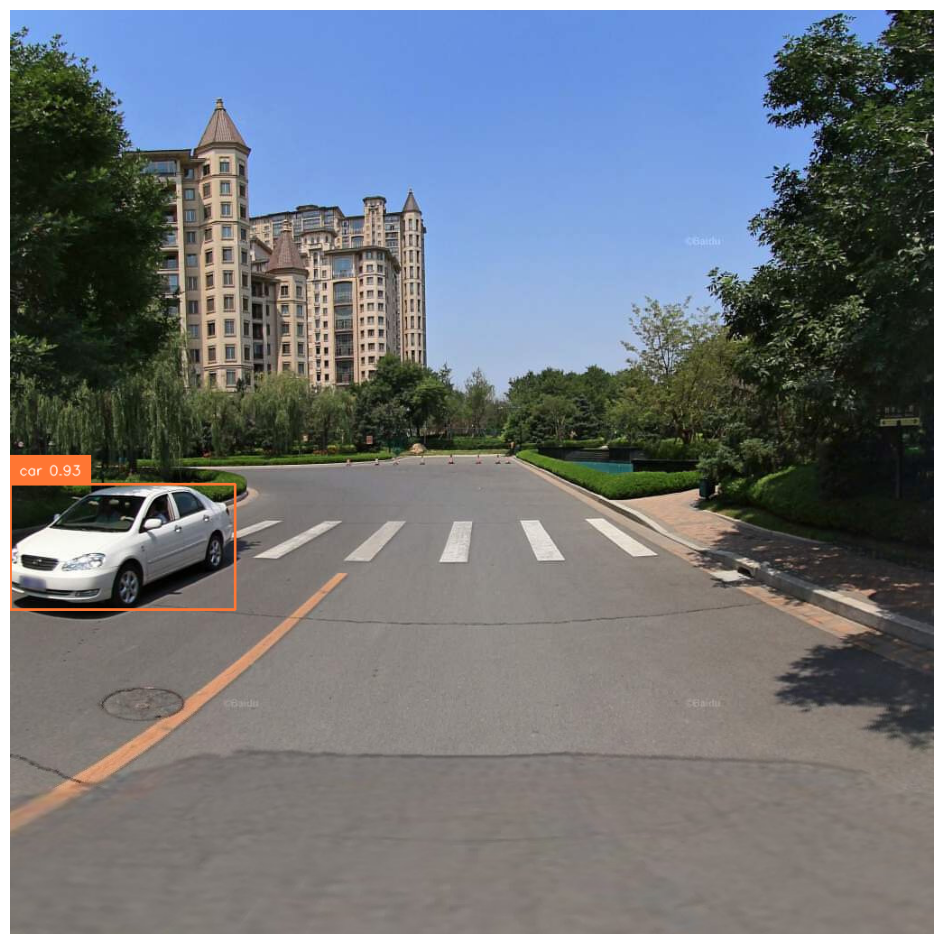

In [ ]:
import os
import supervision as sv
from PIL import Image
from io import BytesIO
import requests
from rfdetr import RFDETRBase
from rfdetr.util.coco_classes import COCO_CLASSES
import matplotlib.pyplot as plt


model = RFDETRBase()

image_path = "./SVRDD_COCO/train/0100220000130723123413672J1_1297245100_482855900.jpg"

image = Image.open(image_path)

print("image =", image)

detections = model.predict(image, threshold=0.5)
print("detections =", detections)


labels = [
    f"{COCO_CLASSES[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()
annotated_image = sv.BoxAnnotator().annotate(annotated_image, detections)
annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels)
annotated_image.save("resultado.png")

sv.plot_image(annotated_image)

# Evaluation

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
import numpy as np
from supervision import Detections
from tqdm import tqdm

def detections_to_coco(detections, image_id):
    """
    Converte Detections (ou lista de Detections) para o formato COCO.
    
    Args:
        detections: Union[Detections, List[Detections]]
        image_ids: List[int] — IDs das imagens na mesma ordem
    
    Returns:
        List[dict] — predições no formato COCO
    """
    results = []

    # Caso seja apenas um Detections
    if isinstance(detections, Detections):
        detections = [detections]

    for xyxy, conf, cls_id in zip(detections.xyxy, detections.confidence, detections.class_id):
        x_min, y_min, x_max, y_max = xyxy
        w = x_max - x_min
        h = y_max - y_min
        results.append({
            "image_id": int(image_id),
            "category_id": int(cls_id),
            "bbox": [float(x_min), float(y_min), float(w), float(h)],
            "score": float(conf)
            })
    return results


def eval_model(model_rfdetr, coco_imgs_path):
    # Loop de predição
    all_predictions = []
    annotation_path = f"{coco_imgs_path}/_annotations.coco.json"
    coco_dataset = COCO(annotation_path)
    img_ids = coco_dataset.getImgIds()

    for img_id in tqdm(img_ids, desc="Gerando predições..."):
        img_info = coco_dataset.loadImgs(img_id)[0]
        img_path = os.path.join(coco_imgs_path, img_info["file_name"])

        # Abre imagem
        img = Image.open(img_path).convert("RGB")

        # Predição com o modelo RF-DETR
        detections = model_rfdetr.predict(img, threshold=0.5)

        # Converte para formato COCO
        preds = detections_to_coco(detections, img_id)
        all_predictions.extend(preds)

    # Salva predições
    coco_preds = json.dumps(all_predictions)

    # 3. Criar avaliador
    cocoEval = COCOeval(coco_dataset, coco_preds, iouType='bbox')
    return cocoEval

In [ ]:
# Caminhos do dataset e onde salvar as predições
COCO_DIR = "./SVRDD_COCO/"
FINETUNED_WEIGHT = ""

TRAIN_PATH = f"{COCO_DIR}/train/"
VAL_PATH = f"{COCO_DIR}/valid/"
TEST_PATH = f"{COCO_DIR}/test/"

TRAIN_ANN_PATH = f"{TRAIN_PATH}/_annotations.coco.json"
VAL_ANN_PATH = f"{VAL_PATH}/_annotations.coco.json"
TEST_ANN_PATH = f"{TEST_PATH}/_annotations.coco.json"


model = RFDETRBase(pretrain_weights=<CHECKPOINT_PATH>)

cocoEval_train = eval_model(model, TRAIN_PATH)
cocoEval_val = eval_model(model, VAL_PATH)
cocoEval_test = eval_model(model, TEST_PATH)

# 4. Parametrizar (por exemplo para IoU 0.50:0.95)
cocoEval_train.evaluate()
cocoEval_train.accumulate()
cocoEval_train.summarize()